### Импорт библиотек

In [1]:
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn import svm

# Часть 5: Решение задачи классификации электронных писем (спам/не спам)

### Пример электронного письма

In [2]:
f = open('./data/emailSample1.txt', 'r').read()
f

"> Anyone knows how much it costs to host a web portal ?\n>\nWell, it depends on how many visitors you're expecting.\nThis can be anywhere from less than 10 bucks a month to a couple of $100. \nYou should checkout http://www.rackspace.com/ or perhaps Amazon EC2 \nif youre running something big..\n\nTo unsubscribe yourself from this mailing list, send an email to:\ngroupname-unsubscribe@egroups.com"

### Загрузка словаря слов

In [3]:
vocab = dict()

with open('./data/vocab.txt', 'r') as v:
    for line in v.readlines():
        n, w = line.split()
        vocab[w] = n

vocab

{'aa': '1',
 'ab': '2',
 'abil': '3',
 'abl': '4',
 'about': '5',
 'abov': '6',
 'absolut': '7',
 'abus': '8',
 'ac': '9',
 'accept': '10',
 'access': '11',
 'accord': '12',
 'account': '13',
 'achiev': '14',
 'acquir': '15',
 'across': '16',
 'act': '17',
 'action': '18',
 'activ': '19',
 'actual': '20',
 'ad': '21',
 'adam': '22',
 'add': '23',
 'addit': '24',
 'address': '25',
 'administr': '26',
 'adult': '27',
 'advanc': '28',
 'advantag': '29',
 'advertis': '30',
 'advic': '31',
 'advis': '32',
 'ae': '33',
 'af': '34',
 'affect': '35',
 'affili': '36',
 'afford': '37',
 'africa': '38',
 'after': '39',
 'ag': '40',
 'again': '41',
 'against': '42',
 'agenc': '43',
 'agent': '44',
 'ago': '45',
 'agre': '46',
 'agreement': '47',
 'aid': '48',
 'air': '49',
 'al': '50',
 'alb': '51',
 'align': '52',
 'all': '53',
 'allow': '54',
 'almost': '55',
 'alon': '56',
 'along': '57',
 'alreadi': '58',
 'alsa': '59',
 'also': '60',
 'altern': '61',
 'although': '62',
 'alwai': '63',
 'am': 

### Функция предобработки содержимого электронного письма и последующего его преобразования в вектор

In [4]:
import re
from nltk.stem import PorterStemmer

def processEmail(email_contents):
    email_contents = email_contents.lower()
    email_contents = re.sub(r'<[^>]+>', '', email_contents)
    email_contents = re.sub(r'http[s]?://[^\s]+', 'httpaddr', email_contents)
    email_contents = re.sub(r'www\.[^\s]+', 'httpaddr', email_contents)
    email_contents = re.sub(r'[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}', 'emailaddr', email_contents)
    email_contents = re.sub(r'\d+(\.\d+)?', 'число', email_contents)
    email_contents = re.sub(r'\$', 'доллар', email_contents)
    email_contents = re.sub(r'[^а-яёa-z\s]+', ' ', email_contents)
    email_contents = re.sub(r'\s+', ' ', email_contents)

    stemmer = PorterStemmer()
    words = email_contents.split()
    stemmed_words = [stemmer.stem(word) for word in words if word.strip()]

    processed_email = ' '.join(stemmed_words).strip()

    bag_of_words = list()
    for word in stemmed_words:
        if word in vocab:
            bag_of_words.append(int(vocab[word]))

    return processed_email, bag_of_words

### Функция генерации вектора признаков для каждого письма

In [5]:
def emailFeatures(bag_of_words):
    n = len(vocab)
    x = [0 for i in range(n)]
    for i in bag_of_words:
        x[i] = 1
    return x

### Предобработка содержимого электронного письма

In [6]:
processed_email, bag_of_words = processEmail(f)
print(processed_email)
print(bag_of_words)

anyon know how much it cost to host a web portal well it depend on how mani visitor you re expect thi can be anywher from less than число buck a month to a coupl of долларчисло you should checkout httpaddr or perhap amazon ecчисло if your run someth big to unsubscrib yourself from thi mail list send an email to emailaddr
[86, 916, 794, 1077, 883, 370, 1699, 790, 1822, 1831, 883, 431, 1171, 794, 1002, 1893, 1364, 592, 1676, 238, 162, 89, 688, 945, 1663, 1062, 1699, 375, 1162, 1893, 1510, 799, 1182, 1237, 810, 1895, 1440, 1547, 181, 1699, 1758, 1896, 688, 1676, 992, 961, 1477, 71, 530, 1699, 531]


### Функция отображения облако слов содержимого электронного письма

In [7]:
from collections import Counter
from wordcloud import WordCloud

def bag_of_words_plot(bag_of_words):
    vocab_reversed = {idx: word for word, idx in vocab.items()}
    words = [vocab_reversed[str(i)] for i in bag_of_words]
    counter = Counter(words)
    wc = WordCloud(width=800, height=400).generate_from_frequencies(counter)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.show()

### Изображения облака слов для загруженного письма

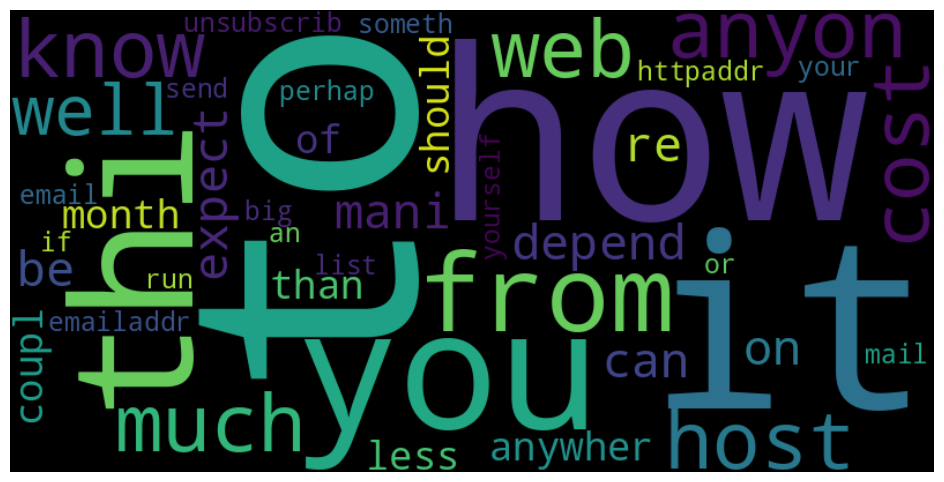

In [8]:
bag_of_words_plot(bag_of_words)

### Инициализация вектора признаков для загруженного письма

In [9]:
features = emailFeatures(bag_of_words)
print(f'Features: {features}\nNot null elements number: {len([i for i in features if i != 0])}')

Features: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### Загрузка данных

In [10]:
data_spam_train = loadmat('./data/spamTrain.mat')
X_train = data_spam_train["X"]
y_train = data_spam_train["y"].ravel()

data_spam_test = loadmat('./data/spamTest.mat')
X_test = data_spam_test["Xtest"]
y_test = data_spam_test["ytest"].ravel()

### Обучение SVC классификатора

In [11]:
svc_classifier = svm.SVC(kernel='linear', C=0.1, gamma=10)
svc_classifier.fit(X_train, y_train)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,10
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Оценка качества обучения SVC классификатора

In [12]:
print(f'SVC score on train data: {svc_classifier.score(X_train, y_train)}')
print(f'SVC score on test data: {svc_classifier.score(X_test, y_test)}')

SVC score on train data: 0.99825
SVC score on test data: 0.989


### Проверка SVC классификатора на реальных данных

In [13]:
def test_spam_model(svc, file_name):
    f = open(f'./data/{file_name}', 'r').read()
    _, bag_of_words = processEmail(f)
    bag_of_words_plot(bag_of_words)
    features = emailFeatures(bag_of_words)
    prediction = svc.predict([features])
    print(f'Prediction for {file_name}: {'Spam' if prediction else 'Email'}')

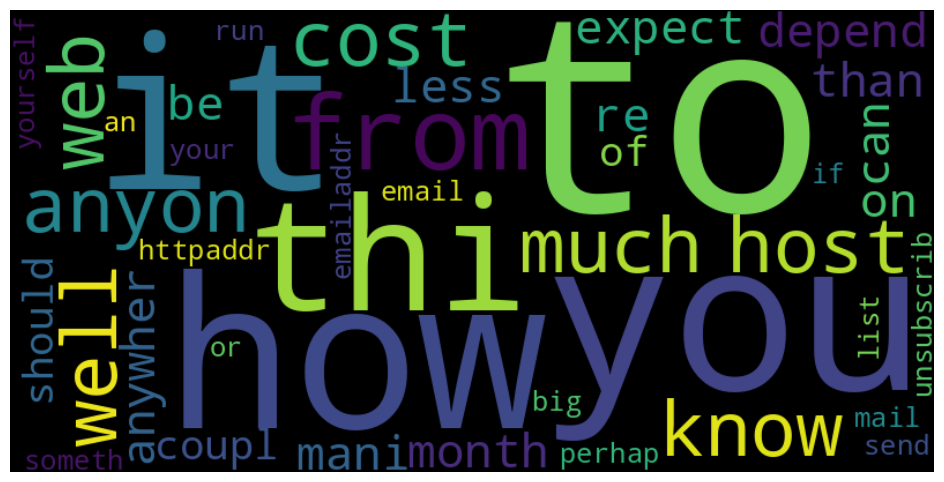

Prediction for emailSample1.txt: Email


In [14]:
test_spam_model(svc_classifier, 'data/emailSample1.txt')

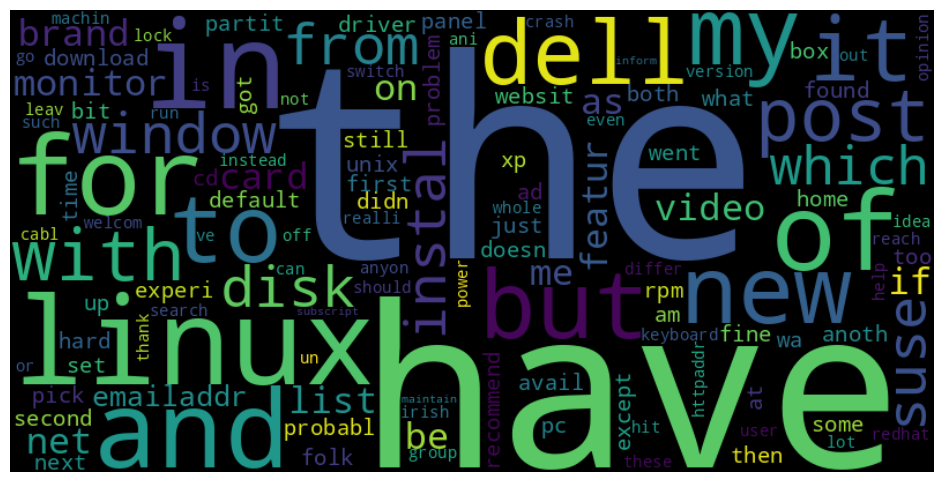

Prediction for emailSample2.txt: Email


In [15]:
test_spam_model(svc_classifier, 'data/emailSample2.txt')

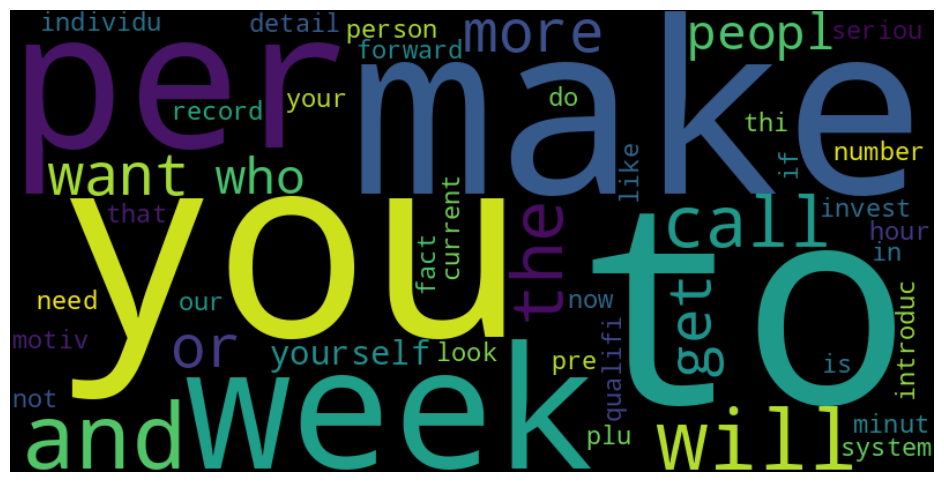

Prediction for spamSample1.txt: Spam


In [16]:
test_spam_model(svc_classifier, 'data/spamSample1.txt')

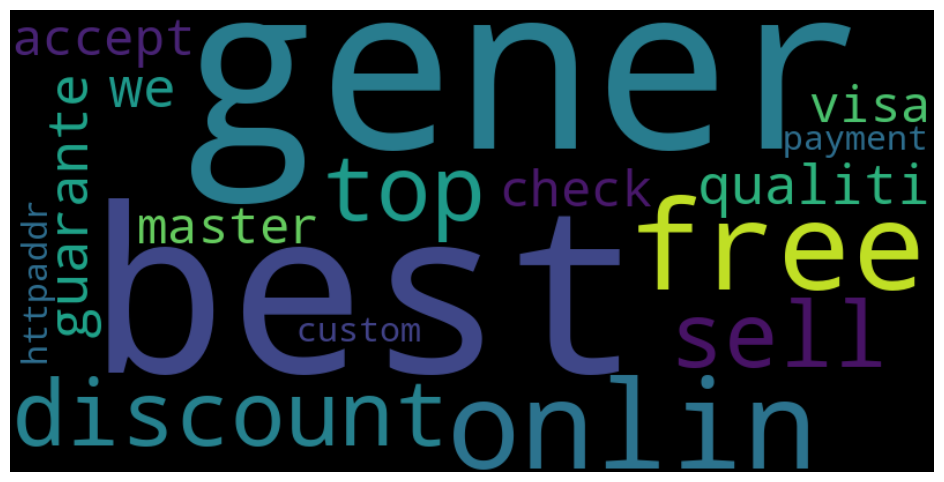

Prediction for spamSample2.txt: Spam


In [17]:
test_spam_model(svc_classifier, 'data/spamSample2.txt')